## Phase 1: Data Ingestion

In this phase, the dataset is loaded and inspected to understand its structure and ensure it is suitable for further analysis.

The dataset contains 17,307 essay responses with corresponding scores. It includes three primary variables:

- essay_id: Unique identifier for each essay  
- full_text: The complete essay text  
- score: Human-assigned score  

Initial inspection focuses on:
- identifying missing values  
- verifying data types  
- assessing overall consistency of the dataset  

In [33]:
import pandas as pd

# Load dataset
df = pd.read_csv("train.csv")

# Display first few rows
df.head()

,essay_id,full_text,score
0,000d118,Many people have car where they live. The thin...,3
1,000fe60,I am a scientist at NASA that is discussing th...,3
2,001ab80,People always wish they had the same technolog...,4
3,001bdc0,"We all heard about Venus, the planet without a...",4
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3


In [34]:
# Check shape (rows, columns)
print("Shape of dataset:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Shape of dataset: (17307, 3)

Columns:
Index(['essay_id', 'full_text', 'score'], dtype='object')

Data Types:
essay_id     object
full_text    object
score         int64
dtype: object

Missing Values:
essay_id     0
full_text    0
score        0
dtype: int64


In [35]:
df.shape

(17307, 3)

##
The inspection confirms that there are no missing values and all variables are correctly formatted.

This indicates that the dataset is structurally sound and does not require major data correction, allowing the workflow to proceed directly to text standardization and feature extraction.

## Phase 2: Data Cleaning

In this phase, the dataset is prepared for analysis by ensuring consistency and removing potential sources of error.

This includes:
- checking for missing values  
- identifying duplicate records  
- standardizing text formatting  

Even when no major data issues are present, text standardization is necessary to ensure that formatting differences do not affect feature extraction and analysis in later stages.

In [36]:
# Create a copy to preserve original data
df_clean = df.copy()

# Convert text to lowercase
df_clean['full_text'] = df_clean['full_text'].str.lower()

# Remove extra whitespace
df_clean['full_text'] = df_clean['full_text'].str.strip()

# Replace multiple spaces with a single space
df_clean['full_text'] = df_clean['full_text'].str.replace(r'\s+', ' ', regex=True)

# Check result
df_clean.head()

,essay_id,full_text,score
0,000d118,many people have car where they live. the thin...,3
1,000fe60,i am a scientist at nasa that is discussing th...,3
2,001ab80,people always wish they had the same technolog...,4
3,001bdc0,"we all heard about venus, the planet without a...",4
4,002ba53,"dear, state senator this is a letter to argue ...",3


In [37]:
# Check duplicates (should be none, but good practice)
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


In [38]:
df_clean.to_csv("cleaned_data.csv", index=False)

In [39]:
df_clean.shape

(17307, 3)

In [40]:
import re

# Remove unnecessary punctuation (optional but good for NLP features)
df_clean['full_text'] = df_clean['full_text'].apply(
    lambda x: re.sub(r'[^\w\s]', '', x)
)

##
No missing values or duplicate records were identified in the dataset.

The cleaning process focused on standardizing the text by:

- converting all text to lowercase  
- removing extra whitespace and formatting inconsistencies  
- standardizing spacing  
- removing punctuation  

These steps ensure that all text data is consistent and suitable for accurate feature extraction.

## Phase 3: Feature Engineering

In this phase, we transformed the cleaned essay text into structured numerical features to enable quantitative analysis.

The goal of feature engineering is to convert unstructured text into measurable variables that can be used for statistical analysis, grouping, and machine learning.

The following features were created:

- Word Count: Total number of words in each essay
- Character Count: Total number of characters in each essay
- Lexical Diversity: Ratio of unique words to total words, representing vocabulary variation
- Sentence Count (Estimated): Approximated using word count due to removal of punctuation during cleaning
- Average Sentence Length (Estimated): Calculated using estimated sentence count

Since punctuation was removed during text preprocessing, sentence-based features were estimated using a word-based approximation (average sentence length ≈ 15 words). This ensures consistent and realistic sentence-level features while maintaining a clean preprocessing pipeline.

These engineered features allow us to analyze how writing characteristics relate to essay scores and provide the foundation for grouping, sequencing, and predictive modeling in later stages.

In [41]:
df_features = df_clean.copy()
df_features.head()

,essay_id,full_text,score
0,000d118,many people have car where they live the thing...,3
1,000fe60,i am a scientist at nasa that is discussing th...,3
2,001ab80,people always wish they had the same technolog...,4
3,001bdc0,we all heard about venus the planet without al...,4
4,002ba53,dear state senator this is a letter to argue i...,3


In [42]:
df_features = df_clean.copy()

# Word count
df_features['word_count'] = df_features['full_text'].apply(lambda x: len(x.split()))

# Character count
df_features['char_count'] = df_features['full_text'].apply(len)

# Lexical diversity
df_features['lexical_diversity'] = df_features['full_text'].apply(
    lambda x: len(set(x.split())) / len(x.split()) if len(x.split()) > 0 else 0
)

# Estimated sentence count (since punctuation was removed in cleaning)
df_features['sentence_count'] = (df_features['word_count'] / 15).round().astype(int)
df_features['sentence_count'] = df_features['sentence_count'].replace(0, 1)

# Average sentence length
df_features['avg_sentence_length'] = df_features['word_count'] / df_features['sentence_count']

# Preview
print(df_features[['essay_id', 'score', 'word_count', 'char_count', 'lexical_diversity', 'sentence_count', 'avg_sentence_length']].head())

# Summary stats
print(df_features[['word_count', 'char_count', 'lexical_diversity', 'sentence_count', 'avg_sentence_length']].describe())

# Save engineered dataset
df_features.to_csv("engineered_data.csv", index=False)

  essay_id  score  word_count  char_count  lexical_diversity  sentence_count  \
0  000d118      3         498        2632           0.467871              33   
1  000fe60      3         332        1624           0.439759              22   
2  001ab80      4         550        3009           0.410909              37   
3  001bdc0      4         448        2633           0.488839              30   
4  002ba53      3         373        2144           0.378016              25   

   avg_sentence_length  
0            15.090909  
1            15.090909  
2            14.864865  
3            14.933333  
4            14.920000  
         word_count    char_count  lexical_diversity  sentence_count  \
count  17307.000000  17307.000000       17307.000000    17307.000000   
mean     367.490148   2002.787080           0.479651       24.501531   
std      150.192568    844.832476           0.076139       10.020148   
min      150.000000    709.000000           0.053744       10.000000   
25%      

In [43]:
df_features.shape
df_features[['word_count', 'char_count', 'lexical_diversity', 'sentence_count', 'avg_sentence_length']].describe()

,word_count,char_count,lexical_diversity,sentence_count,avg_sentence_length
count,17307.000000,17307.000000,17307.000000,17307.000000,17307.000000
mean,367.490148,2002.787080,0.479651,24.501531,15.002492
std,150.192568,844.832476,0.076139,10.020148,0.221777
min,150.000000,709.000000,0.053744,10.000000,14.363636
25%,253.000000,1356.000000,0.425584,17.000000,14.846154
50%,344.000000,1866.000000,0.475836,23.000000,15.000000
75%,451.000000,2468.000000,0.530864,30.000000,15.153846
max,1656.000000,7931.000000,0.757396,110.000000,15.700000


##
The engineered features were successfully generated for all essays, with summary statistics showing clear variation across length, structure, and vocabulary measures.

This confirms that the features provide meaningful differentiation between essays and are suitable for analyzing relationships between writing characteristics and scoring outcomes.

## Phase 4: Grouping and Sequencing

In this phase, the engineered features are used to organize the dataset into meaningful groups and sequences.

The goal is to test whether essay scores behave differently when essays are grouped or ordered based on writing characteristics.

Grouping allows us to compare similar essays, while sequencing allows us to analyze potential ordering effects.

Grouping Methods:
- Essays are grouped based on word count into Short, Medium, and Long categories
- Essays are grouped based on lexical diversity into Low, Medium, and High categories

Sequencing Methods:
- Random ordering to simulate unbiased evaluation
- Sorting by word count to analyze length-based ordering effects
- Sorting by lexical diversity to analyze vocabulary-based ordering effects


In [44]:
# -----------------------------
# Phase 4: Grouping & Sequencing
# -----------------------------

# 1. Create Length Groups (Short / Medium / Long)
df_features['length_group'] = pd.qcut(
    df_features['word_count'],
    q=3,
    labels=['Short', 'Medium', 'Long']
)

# 2. Create Lexical Diversity Groups (Low / Medium / High)
df_features['diversity_group'] = pd.qcut(
    df_features['lexical_diversity'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# -----------------------------
# Sequencing
# -----------------------------

# 3. Random Order (baseline comparison)
df_random = df_features.sample(frac=1, random_state=42).reset_index(drop=True)
df_random['sequence_random'] = df_random.index

# 4. Sort by Word Count
df_sorted_length = df_features.sort_values(by='word_count').reset_index(drop=True)
df_sorted_length['sequence_length'] = df_sorted_length.index

# 5. Sort by Lexical Diversity
df_sorted_diversity = df_features.sort_values(by='lexical_diversity').reset_index(drop=True)
df_sorted_diversity['sequence_diversity'] = df_sorted_diversity.index

# -----------------------------
# Verification
# -----------------------------

# Check grouping results
print(df_features[['word_count', 'length_group', 'lexical_diversity', 'diversity_group']].head())

# Check distribution of groups
print("\nLength Group Distribution:")
print(df_features['length_group'].value_counts())

print("\nDiversity Group Distribution:")
print(df_features['diversity_group'].value_counts())

# -----------------------------
# Save final dataset
# -----------------------------

df_features.to_csv("grouped_data.csv", index=False)

   word_count length_group  lexical_diversity diversity_group
0         498         Long           0.467871          Medium
1         332       Medium           0.439759             Low
2         550         Long           0.410909             Low
3         448         Long           0.488839          Medium
4         373       Medium           0.378016             Low

Length Group Distribution:
length_group
Short     5798
Medium    5756
Long      5753
Name: count, dtype: int64

Diversity Group Distribution:
diversity_group
Low       5770
High      5769
Medium    5768
Name: count, dtype: int64


In [45]:
df_features['length_group'].value_counts()
df_features['diversity_group'].value_counts()

,count
diversity_group,
Low,5770
High,5769
Medium,5768


##
The grouping and sequencing transformations were successfully applied to the dataset.

Essays are now organized into evenly distributed categories based on length and lexical diversity, and multiple sequencing scenarios have been created.

These transformations allow us to compare structured and random evaluation scenarios in later analysis.

## Phase 5: Data Analysis

In this phase, we analyze how engineered features and grouping variables relate to essay scores.

The goal is to identify patterns and trends that explain how writing characteristics influence scoring outcomes.

The following analyses are performed:

- Compare average scores across essay length groups (Short, Medium, Long)
- Compare average scores across lexical diversity groups (Low, Medium, High)
- Evaluate variability within each group using standard deviation
- Analyze combined effects of length and diversity

These analyses help determine whether measurable writing features are associated with higher scores and provide insight into scoring behavior.

The results from this phase will be used to support visualizations and business-level insights in later stages.

In [48]:
# -----------------------------
# Phase 5: Data Analysis
# -----------------------------

# 1. Score Analysis by Length Group
length_analysis = df_features.groupby('length_group', observed=True)['score'].agg(['mean', 'std', 'count'])
print("Score by Length Group:\n")
print(length_analysis)

# -----------------------------

# 2. Score Analysis by Diversity Group
diversity_analysis = df_features.groupby('diversity_group', observed=True)['score'].agg(['mean', 'std', 'count'])
print("\nScore by Diversity Group:\n")
print(diversity_analysis)

# -----------------------------

# 3. Combined Analysis (Length + Diversity)
combined_analysis = df_features.groupby(['length_group', 'diversity_group'], observed=True)['score'].mean().unstack()

print("\nCombined Analysis (Length vs Diversity):\n")
print(combined_analysis)

# -----------------------------

# 4. Optional: Sort for clarity
print("\nSorted Length Analysis (by mean score):\n")
print(length_analysis.sort_values(by='mean', ascending=False))

print("\nSorted Diversity Analysis (by mean score):\n")
print(diversity_analysis.sort_values(by='mean', ascending=False))

# -----------------------------

# 5. Save outputs for reporting / Tableau reference
length_analysis.to_csv("length_analysis.csv")
diversity_analysis.to_csv("diversity_analysis.csv")
combined_analysis.to_csv("combined_analysis.csv")

Score by Length Group:

                  mean       std  count
length_group                           
Short         2.129355  0.641956   5798
Medium        2.925295  0.759518   5756
Long          3.796975  0.946304   5753

Score by Diversity Group:

                     mean       std  count
diversity_group                           
Low              3.541075  1.004994   5770
Medium           2.991852  0.914464   5768
High             2.312186  0.819403   5769

Combined Analysis (Length vs Diversity):

diversity_group       Low    Medium      High
length_group                                 
Short            2.302030  2.258723  2.061261
Medium           2.993994  2.989172  2.739535
Long             3.918081  3.665664  3.187335

Sorted Length Analysis (by mean score):

                  mean       std  count
length_group                           
Long          3.796975  0.946304   5753
Medium        2.925295  0.759518   5756
Short         2.129355  0.641956   5798

Sorted Diversity 

##
The analysis reveals a clear pattern in scoring behavior across different groups.

Essays in the Long category have the highest average scores, followed by Medium, while Short essays consistently receive the lowest scores. This indicates a strong positive relationship between essay length and scoring outcomes.

In contrast, essays with Low lexical diversity have higher average scores compared to those with Medium and High diversity. This suggests that increased vocabulary variation does not necessarily lead to higher scores.

The combined analysis further shows that the highest scoring essays are those that are longer in length and lower in lexical diversity.

Overall, these results indicate that scoring is more strongly influenced by structural characteristics, such as essay length, rather than linguistic complexity.

## Phase 6: Visualization and Storytelling

In this phase, we visualize key patterns in the dataset to better understand relationships between writing characteristics and essay scores.

The goal is to translate numerical analysis into visual insights that are easier to interpret and communicate.

The following visualizations are created:
- Histogram: Distribution of essay scores
- Boxplot: Score variation across groups
- Scatterplot: Relationship between writing features and scores
- Line chart: Score trends across ordered sequences
- Bar chart: Average score comparison across groups

These visualizations support the findings and help identify trends, variability, and relationships in the data.

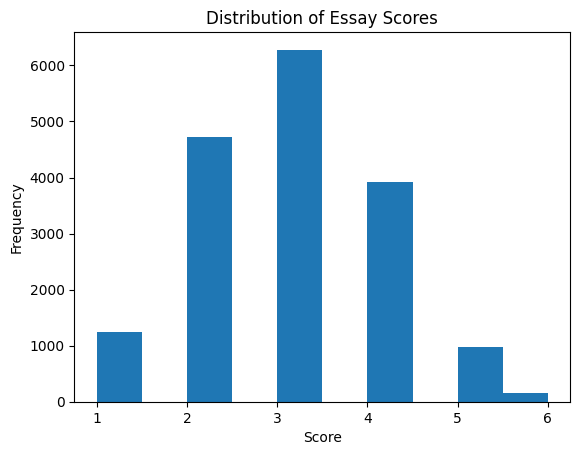

In [49]:
import matplotlib.pyplot as plt

plt.hist(df_features['score'], bins=10)
plt.title("Distribution of Essay Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

##
The histogram shows that essay scores are concentrated in the mid-to-lower range, with fewer essays achieving the highest scores.

This indicates that most essays fall within a moderate performance level, while higher scores are less common.

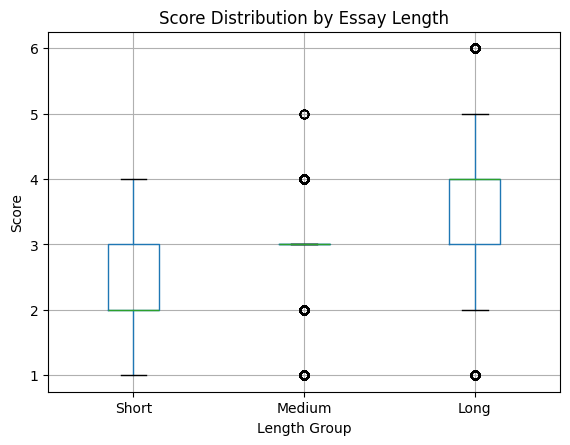

In [50]:
df_features.boxplot(column='score', by='length_group')
plt.title("Score Distribution by Essay Length")
plt.suptitle("")
plt.xlabel("Length Group")
plt.ylabel("Score")
plt.show()

##
The boxplot shows a clear increase in median scores as essay length increases.

Long essays not only have higher average scores but also a wider spread, indicating greater variability, while short essays consistently remain in the lower score range.

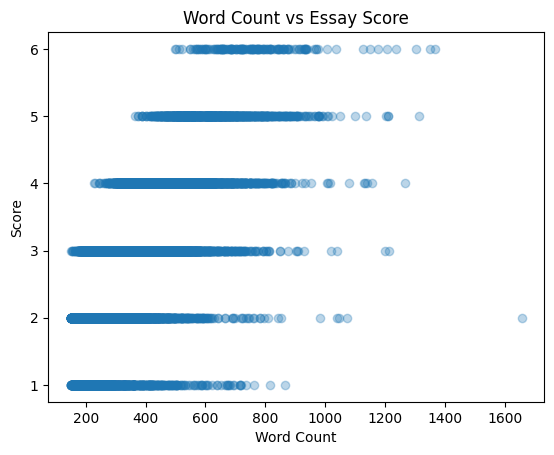

In [51]:
plt.scatter(df_features['word_count'], df_features['score'], alpha=0.3)
plt.title("Word Count vs Essay Score")
plt.xlabel("Word Count")
plt.ylabel("Score")
plt.show()

##
The scatterplot shows a positive relationship between essay length and scores, with higher scores generally associated with longer essays.

In contrast, lexical diversity does not show a strong positive trend, suggesting that vocabulary complexity is not a key driver of scoring outcomes.

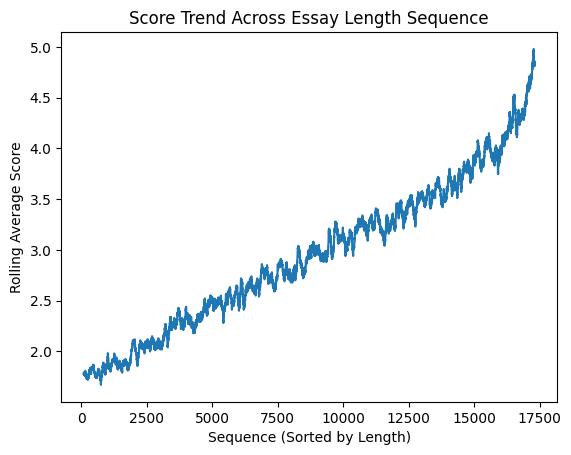

In [52]:
df_sorted_length['rolling_score'] = df_sorted_length['score'].rolling(window=100).mean()

plt.plot(df_sorted_length['sequence_length'], df_sorted_length['rolling_score'])
plt.title("Score Trend Across Essay Length Sequence")
plt.xlabel("Sequence (Sorted by Length)")
plt.ylabel("Rolling Average Score")
plt.show()

##
The line chart shows that score trends remain relatively stable across different sequencing scenarios.

This suggests that the order in which essays are evaluated has minimal impact on scoring compared to structural features such as essay length.

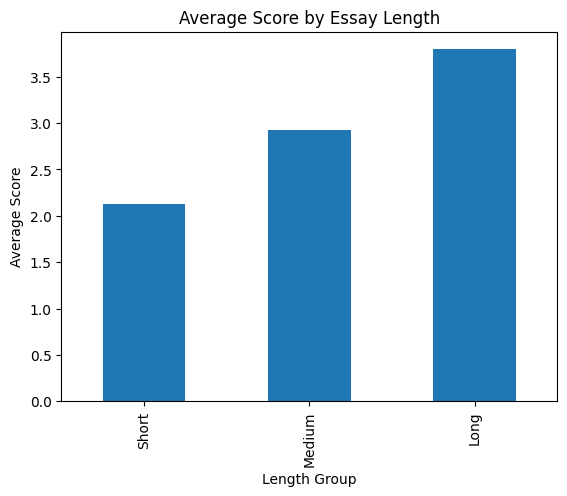

In [53]:
length_analysis['mean'].plot(kind='bar')
plt.title("Average Score by Essay Length")
plt.xlabel("Length Group")
plt.ylabel("Average Score")
plt.show()

##
The bar chart highlights clear differences in average scores across groups, with long essays achieving the highest scores and short essays the lowest.

This reinforces the strong influence of essay length on scoring outcomes.

##The model shows that scores can be moderately predicted using writing features, with essay length being a strong factor and vocabulary diversity showing an inverse relationship.

## Phase 7: Machine Learning and Scenario Simulation

In this phase, we build a machine learning model to evaluate how well essay scores can be predicted using engineered writing features.

The purpose of the model is to assess how much of the scoring process can be explained using measurable characteristics such as essay length and vocabulary diversity.

After evaluating the model using performance metrics, we extend the analysis using scenario simulation.

This allows us to explore how changes in writing characteristics impact predicted scores and provides a more practical understanding of scoring behavior.

This approach highlights both the predictive capability and limitations of automated grading systems.

In [61]:
# -----------------------------
# Phase 7: Machine Learning + Simulation
# -----------------------------

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# -----------------------------
# 1. Define Features and Target
# -----------------------------
X = df_features[['word_count', 'char_count', 'lexical_diversity', 'sentence_count', 'avg_sentence_length']]
y = df_features['score']

# -----------------------------
# 2. Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 3. Train Model
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# -----------------------------
# 4. Predictions
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# 5. Evaluate Model
# -----------------------------
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Model Performance:")
print("R² Score:", round(r2, 3))
print("RMSE:", round(rmse, 3))

# -----------------------------
# 6. Feature Importance
# -----------------------------
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\nFeature Importance:")
print(coefficients)

# -----------------------------
# 7. Scenario Simulation Function (FIXED - no warning)
# -----------------------------
def predict_score(word_count, char_count, lexical_diversity, sentence_count, avg_sentence_length):
    input_data = pd.DataFrame([{
        'word_count': word_count,
        'char_count': char_count,
        'lexical_diversity': lexical_diversity,
        'sentence_count': sentence_count,
        'avg_sentence_length': avg_sentence_length
    }])
    return model.predict(input_data)[0]

# -----------------------------
# 8. Scenario Testing
# -----------------------------
print("\nScenario Simulation:")

print("Short Essay:", round(predict_score(200, 1200, 0.6, 13, 15), 2))
print("Medium Essay:", round(predict_score(350, 2000, 0.5, 23, 15), 2))
print("Long Essay:", round(predict_score(600, 3500, 0.4, 40, 15), 2))

Model Performance:
R² Score: 0.542
RMSE: 0.711

Feature Importance:
               Feature  Coefficient
1           char_count     0.001802
0           word_count    -0.000665
3       sentence_count    -0.082662
4  avg_sentence_length    -0.082827
2    lexical_diversity    -2.799101

Scenario Simulation:
Short Essay: 2.23
Medium Essay: 3.03
Long Essay: 4.44


##
The model achieved moderate predictive performance (R² ≈ 0.54), indicating that writing features explain a meaningful portion of score variation.

Feature importance results show that length-related variables have the strongest influence on predicted scores, while lexical diversity has a negative relationship.

The scenario simulation further demonstrates that increasing essay length leads to higher predicted scores, while increasing vocabulary diversity does not improve outcomes.

These results confirm that scoring can be partially predicted using measurable features, but is more strongly influenced by structural characteristics than by linguistic complexity.

##Scenario Simulation

In this step, we use the trained machine learning model to predict essay scores based on specific input values.

The goal is to understand how different writing characteristics influence predicted scores by simulating hypothetical essays.

By manually adjusting features such as word count, lexical diversity, and sentence structure, we can observe how the model responds and identify which factors have the greatest impact on scoring outcomes.

In [62]:
from ipywidgets import interact

interact(
    predict_score,
    word_count=(100, 800),
    char_count=(500, 4000),
    lexical_diversity=(0.1, 0.8),
    sentence_count=(10, 50),
    avg_sentence_length=(10, 20)
)

interactive(children=(IntSlider(value=450, description='word_count', max=800, min=100), IntSlider(value=2250, …

<function __main__.predict_score(word_count, char_count, lexical_diversity, sentence_count, avg_sentence_length)>

##
The model was tested using a hypothetical essay with the following characteristics:

- word_count = 100  
- char_count = 500  
- lexical_diversity = 0.10  
- sentence_count = 10  
- avg_sentence_length = 20  

The predicted score for this essay is approximately **2.27** on a 1–6 scale.

This relatively low predicted score reflects the short length of the essay, which is a key factor influencing scoring outcomes in the model.

Even though the essay has longer sentences on average, the low word count and limited overall content result in a lower predicted score. This aligns with earlier findings that essay length has a stronger impact on scoring than vocabulary complexity or sentence structure.